***EX NO 5 - CLASSIFICATION USING K-NEAREST NEIGHBORS (KNN) AND DECISION TREE***

**DATE: 19.02.2026**


**-SREENIDHI S (24BAD114)**

SCENARIO 1 – K-NEAREST NEIGHBORS (KNN)

Problem Statement
Predict whether a tumor is benign or malignant based on medical measurements.
Dataset (Kaggle – Public)
Breast Cancer Dataset
Dataset Link: https://www.kaggle.com/datasets/yasserh/breast-cancer-dataset

Target Variable: Diagnosis (Benign / Malignant)
Input Feature:  • Radius • Texture • Perimeter • Area • Smoothness

IN-LAB TASKS (KNN Classification)


Import required Python libraries.
Load the Breast Cancer dataset.
Perform data inspection & preprocessing.
Encode target labels.
Apply feature scaling (very important for KNN).
Split dataset into training and testing sets.
Train a KNN classifier.
Experiment with different values of K.
Predict diagnosis labels.
Evaluate performance using:
• Accuracy
• Precision / Recall / F1 Score
Identify misclassified cases.
Analyze model sensitivity to K.
Visualization
• Confusion Matrix
• Accuracy vs K Plot
• Decision Boundary (using two features)

SREENIDHI - 24BAD114


Saving breast-cancer.csv to breast-cancer (1).csv
DATASET SHAPE: (569, 32)

FIRST 5 ROWS
          id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.19

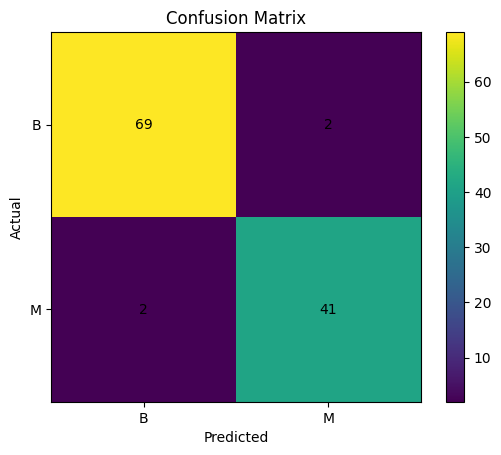


MISCLASSIFIED CASES (First 10)
Actual: B | Predicted: M
Actual: M | Predicted: B
Actual: B | Predicted: M
Actual: M | Predicted: B


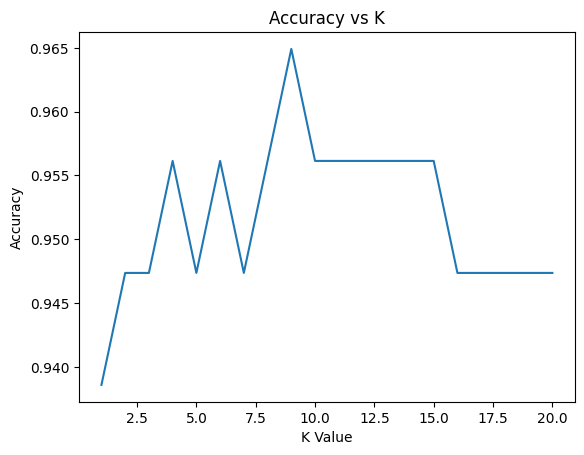

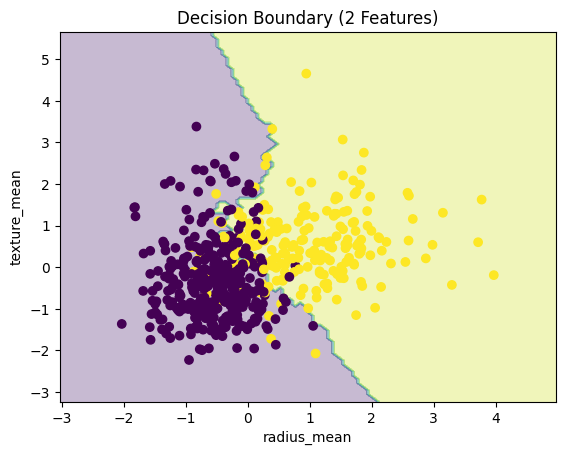

In [1]:
print("SREENIDHI - 24BAD114")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_csv("/content/breast-cancer.csv")

print("DATASET SHAPE:", df.shape)
print("\nFIRST 5 ROWS\n", df.head())

df = df.dropna()

if "id" in df.columns:
    df = df.drop(columns=["id"])

X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

encoder = LabelEncoder()
y = encoder.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

k_values = range(1, 21)
accuracy_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred_k = knn.predict(X_test)
    accuracy_scores.append(accuracy_score(y_test, y_pred_k))

best_k = k_values[np.argmax(accuracy_scores)]

print("\nBEST K VALUE:", best_k)

model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nMODEL PERFORMANCE")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nCLASSIFICATION REPORT\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0,1], encoder.classes_)
plt.yticks([0,1], encoder.classes_)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

misclassified = np.where(y_test != y_pred)[0]

print("\nMISCLASSIFIED CASES (First 10)")
for i in misclassified[:10]:
    print("Actual:", encoder.inverse_transform([y_test[i]])[0],
          "| Predicted:", encoder.inverse_transform([y_pred[i]])[0])

plt.figure()
plt.plot(k_values, accuracy_scores)
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.show()

X_two = X_scaled[:, :2]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_two, y, test_size=0.2, random_state=42)

model2 = KNeighborsClassifier(n_neighbors=best_k)
model2.fit(X_train2, y_train2)

x_min, x_max = X_two[:, 0].min() - 1, X_two[:, 0].max() + 1
y_min, y_max = X_two[:, 1].min() - 1, X_two[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 100),
    np.linspace(y_min, y_max, 100)
)

Z = model2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_two[:, 0], X_two[:, 1], c=y)
plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.title("Decision Boundary (2 Features)")
plt.show()

SCENARIO 2 – DECISION TREE CLASSIFIER

Problem Statement
Predict whether a loan application should be approved or rejected.
Dataset (Public / Standard Dataset)
Loan Prediction Dataset
Dataset Link: https://www.kaggle.com/datasets/ninzaami/loan-predication  
Target Variable: Loan Status (Approved / Rejected)
Input Features: • Applicant Income • Loan Amount • Credit History • Education • Property Area

IN-LAB TASKS (Decision Tree Classification)


Import required Python libraries.
Load the Loan Prediction dataset.
Perform preprocessing:
• Handle missing values
• Encode categorical variables
Split dataset into training and testing sets.
Train a Decision Tree classifier.
Experiment with tree depth / pruning.
Predict loan status.
Evaluate performance using:
• Accuracy
• Precision / Recall / F1 Score
Analyze feature importance.
Detect overfitting behavior.
Compare shallow vs deep trees.
 Visualization
• Confusion Matrix
• Tree Structure Plot
• Feature Importance Plot


SREENIDHI - 24BAD114


Saving train_u6lujuX_CVtuZ9i (1).csv to train_u6lujuX_CVtuZ9i (1) (1).csv
DATASET SHAPE: (614, 13)

FIRST 5 ROWS
     Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status 

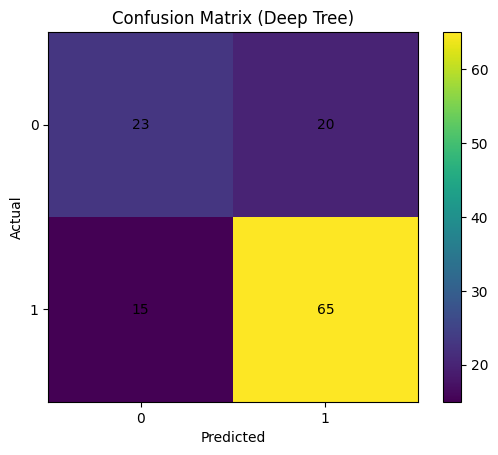

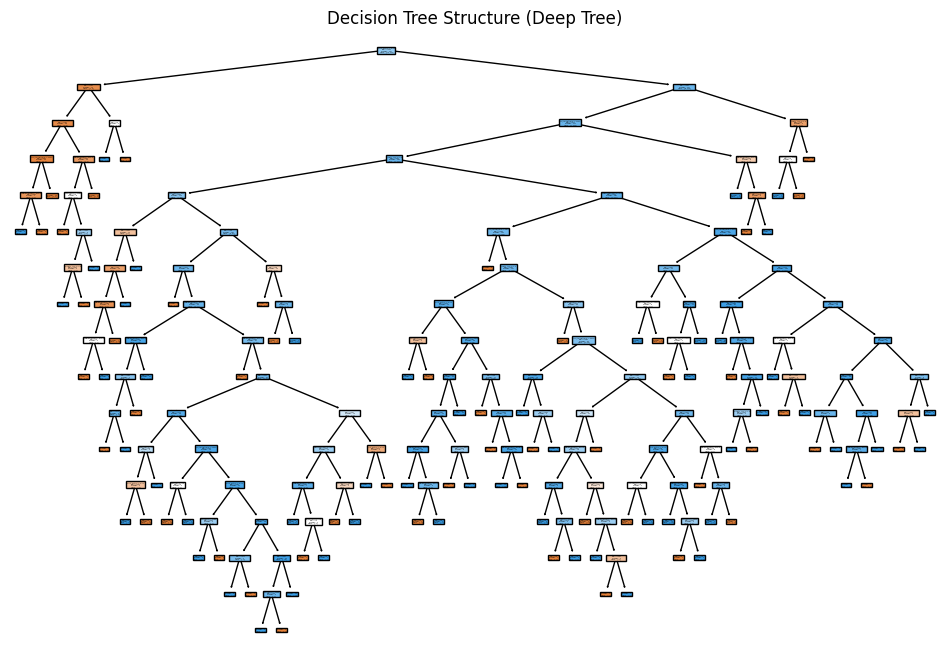

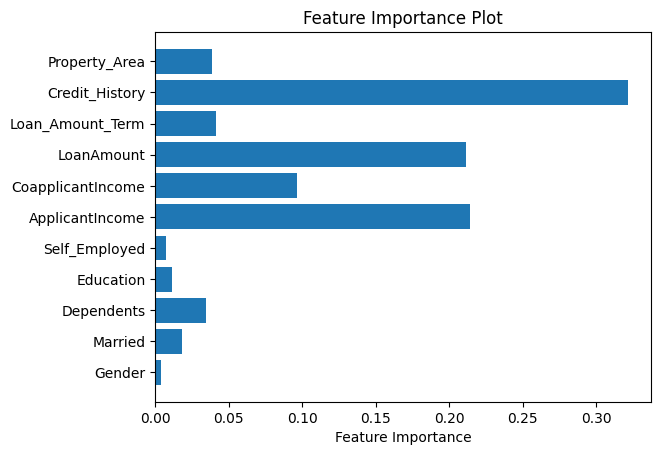


OVERFITTING ANALYSIS
Deep Tree - Train Accuracy : 1.0
Deep Tree - Test Accuracy  : 0.7154471544715447
Shallow Tree - Train Accuracy : 0.8268839103869654
Shallow Tree - Test Accuracy  : 0.7642276422764228


In [2]:
print("SREENIDHI - 24BAD114")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_csv("/content/train_u6lujuX_CVtuZ9i (1).csv")

print("DATASET SHAPE:", df.shape)
print("\nFIRST 5 ROWS\n", df.head())

df = df.drop(columns=[col for col in df.columns if "Loan_ID" in col], errors="ignore")

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].mean())

label_encoders = {}
for col in df.columns:
    if df[col].dtype == "object":
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le

X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

deep_tree = DecisionTreeClassifier(random_state=42)
deep_tree.fit(X_train, y_train)

shallow_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
shallow_tree.fit(X_train, y_train)

y_pred_deep = deep_tree.predict(X_test)
y_pred_shallow = shallow_tree.predict(X_test)

print("\nDEEP TREE PERFORMANCE")
print("Accuracy :", accuracy_score(y_test, y_pred_deep))
print("Precision:", precision_score(y_test, y_pred_deep))
print("Recall   :", recall_score(y_test, y_pred_deep))
print("F1 Score :", f1_score(y_test, y_pred_deep))

print("\nSHALLOW TREE PERFORMANCE")
print("Accuracy :", accuracy_score(y_test, y_pred_shallow))
print("Precision:", precision_score(y_test, y_pred_shallow))
print("Recall   :", recall_score(y_test, y_pred_shallow))
print("F1 Score :", f1_score(y_test, y_pred_shallow))

cm = confusion_matrix(y_test, y_pred_deep)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix (Deep Tree)")
plt.colorbar()
plt.xticks([0,1])
plt.yticks([0,1])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure(figsize=(12,8))
plot_tree(deep_tree, feature_names=X.columns, filled=True)
plt.title("Decision Tree Structure (Deep Tree)")
plt.show()

importances = deep_tree.feature_importances_

plt.figure()
plt.barh(X.columns, importances)
plt.xlabel("Feature Importance")
plt.title("Feature Importance Plot")
plt.show()

train_acc_deep = accuracy_score(y_train, deep_tree.predict(X_train))
test_acc_deep = accuracy_score(y_test, y_pred_deep)

train_acc_shallow = accuracy_score(y_train, shallow_tree.predict(X_train))
test_acc_shallow = accuracy_score(y_test, y_pred_shallow)

print("\nOVERFITTING ANALYSIS")
print("Deep Tree - Train Accuracy :", train_acc_deep)
print("Deep Tree - Test Accuracy  :", test_acc_deep)
print("Shallow Tree - Train Accuracy :", train_acc_shallow)
print("Shallow Tree - Test Accuracy  :", test_acc_shallow)